In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 19:31:23.179 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 19:31:23.544 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 19:31:23.545 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 19:31:23.549 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


2026-05-18 19:31:26.650 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp7boz_2ts/DIFF_PAIR.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:26.941 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpt8e1wkkm/DIFF_PAIR.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmp7boz_2ts/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "DIFF_PAIR".
[INFO]: Loading DIF

2026-05-18 19:31:27.196 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'diff_pair.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "DIFF_PAIR".
Extracting DIFF_PAIR into D

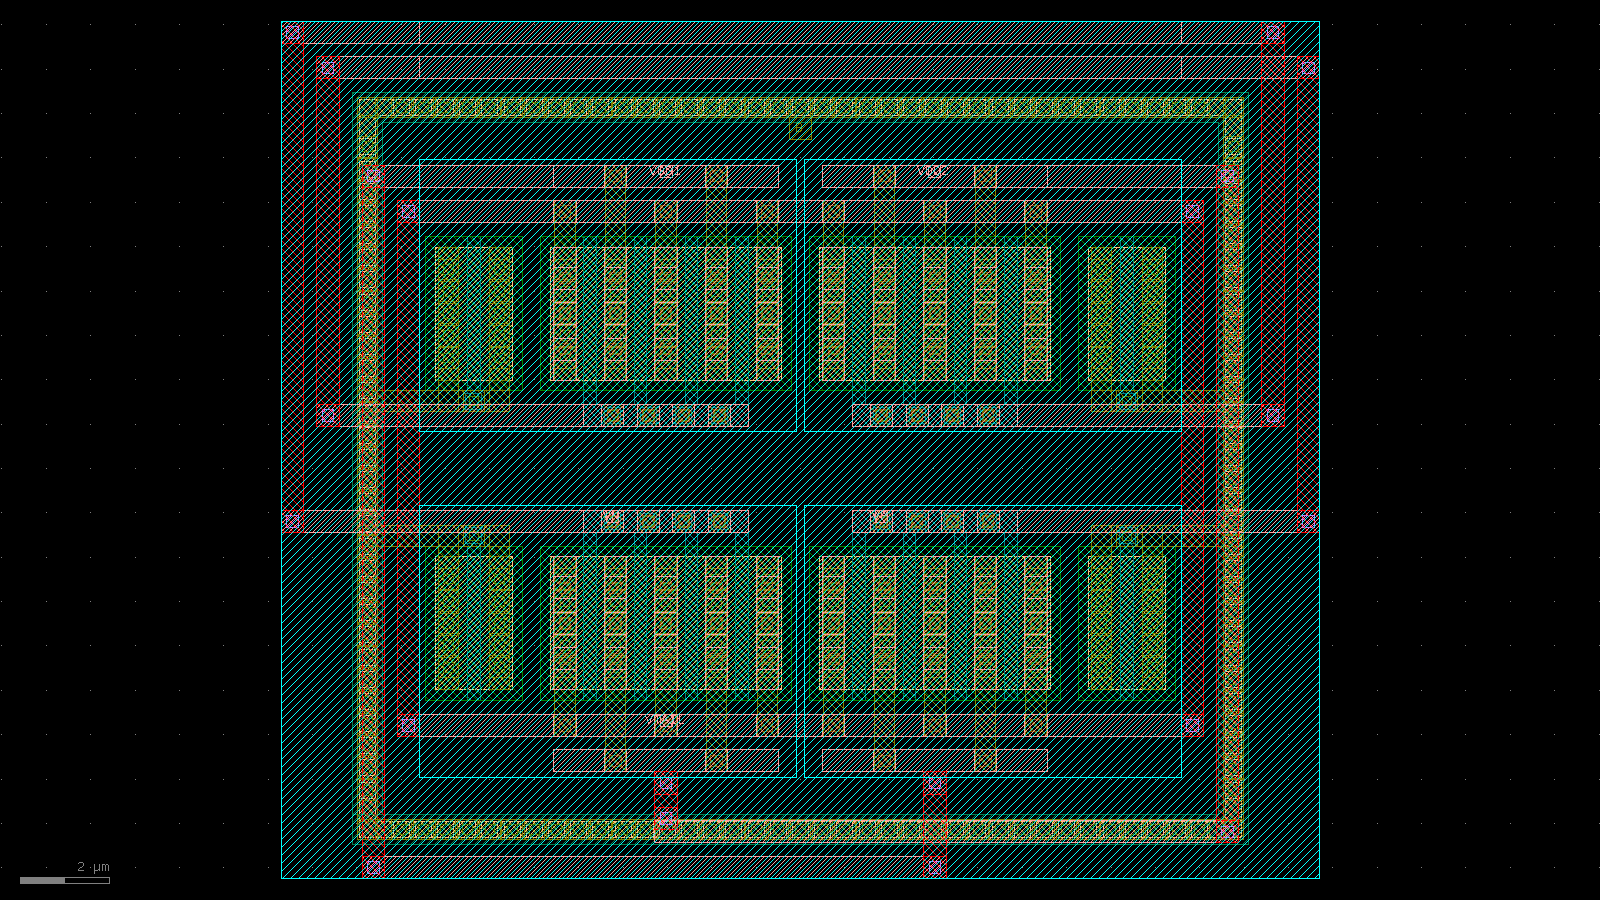

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from typing import Optional, Union

from gdsfactory.cell import cell
from gdsfactory.component import Component, copy
from gdsfactory.components.rectangle import rectangle
from gdsfactory.routing.route_quad import route_quad
from gdsfactory.routing.route_sharp import route_sharp
from glayout.pdk.mappedpdk import MappedPDK
from glayout.util.comp_utils import align_comp_to_port, evaluate_bbox, movex, movey
from glayout.util.port_utils import (
    add_ports_perimeter,
    get_orientation,
    print_ports,
    rename_ports_by_list,
    rename_ports_by_orientation,
    set_port_orientation,
)
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.placement.common_centroid_ab_ba import common_centroid_ab_ba
from glayout.primitives.fet import nmos, pmos
from glayout.primitives.guardring import tapring
from glayout.primitives.via_gen import via_stack
from glayout.routing.c_route import c_route
from glayout.routing.smart_route import smart_route
from glayout.routing.straight_route import straight_route
from glayout.spice import Netlist
from glayout.pdk.gf180_mapped import gf180_mapped_pdk
from gdsfactory.components import text_freetype
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None


def add_df_labels(df_in: Component,
                        pdk: MappedPDK
                         ) -> Component:
	
	df_in.unlock()
	met1_pin = (67,16)
	met1_label = (67,5)
	met2_pin = (68,16)
	met2_label = (68,5)
    # list that will contain all port/comp info
	move_info = list()
    # create labels and append to info list
    # vtail
	vtaillabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
	vtaillabel.add_label(text="VTAIL",layer=pdk.get_glayer("met2_label"))
	move_info.append((vtaillabel,df_in.ports["bl_multiplier_0_source_S"],None))
    
    # vdd1
	vdd1label = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
	vdd1label.add_label(text="VDD1",layer=pdk.get_glayer("met2_label"))
	move_info.append((vdd1label,df_in.ports["tl_multiplier_0_drain_N"],None))
    
    # vdd2
	vdd2label = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
	vdd2label.add_label(text="VDD2",layer=pdk.get_glayer("met2_label"))
	move_info.append((vdd2label,df_in.ports["tr_multiplier_0_drain_N"],None))
    
    # VB
	vblabel = rectangle(layer=pdk.get_glayer("met1_pin"),size=(0.5,0.5),centered=True).copy()
	vblabel.add_label(text="B",layer=pdk.get_glayer("met1_label"))
	move_info.append((vblabel,df_in.ports["tap_N_top_met_S"], None))
    
    # VP
	vplabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
	vplabel.add_label(text="VP",layer=pdk.get_glayer("met2_label"))
	move_info.append((vplabel,df_in.ports["br_multiplier_0_gate_S"], None))
    
    # VN
	vnlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=(0.27,0.27),centered=True).copy()
	vnlabel.add_label(text="VN",layer=pdk.get_glayer("met2_label"))
	move_info.append((vnlabel,df_in.ports["bl_multiplier_0_gate_S"], None))

    # move everything to position
	for comp, prt, alignment in move_info:
		alignment = ('c','b') if alignment is None else alignment
		compref = align_comp_to_port(comp, prt, alignment=alignment)
		df_in.add(compref)
	return df_in.flatten() 

def diff_pair_netlist(fetL: Component, fetR: Component) -> Netlist:
	diff_pair_netlist = Netlist(circuit_name='DIFF_PAIR', nodes=['VP', 'VN', 'VDD1', 'VDD2', 'VTAIL', 'B'])

	# The physical layout uses an AB/BA common-centroid placement with four
	# mirrored device references (two copies of the left device and two copies of
	# the right device). Model that explicitly in the reference netlist so LVS
	# compares against the same effective device count/width.
	diff_pair_netlist.connect_netlist(
		fetL.info['netlist'],
		[('D', 'VDD1'), ('G', 'VP'), ('S', 'VTAIL'), ('B', 'B')]
	)
	diff_pair_netlist.connect_netlist(
		fetL.info['netlist'],
		[('D', 'VDD1'), ('G', 'VP'), ('S', 'VTAIL'), ('B', 'B')]
	)
	diff_pair_netlist.connect_netlist(
		fetR.info['netlist'],
		[('D', 'VDD2'), ('G', 'VN'), ('S', 'VTAIL'), ('B', 'B')]
	)
	diff_pair_netlist.connect_netlist(
		fetR.info['netlist'],
		[('D', 'VDD2'), ('G', 'VN'), ('S', 'VTAIL'), ('B', 'B')]
	)
	return diff_pair_netlist

@cell
def diff_pair(
	pdk: MappedPDK,
	width: float = 3,
	fingers: int = 4,
	length: Optional[float] = None,
	n_or_p_fet: bool = True,
	plus_minus_seperation: float = 0,
	rmult: int = 1,
	dummy: Union[bool, tuple[bool, bool]] = True,
	substrate_tap: bool=True
) -> Component:
	"""create a diffpair with 2 transistors placed in two rows with common centroid place. Sources are shorted
	width = width of the transistors
	fingers = number of fingers in the transistors (must be 2 or more)
	length = length of the transistors, None or 0 means use min length
	short_source = if true connects source of both transistors
	n_or_p_fet = if true the diffpair is made of nfets else it is made of pfets
	substrate_tap: if true place a tapring around the diffpair (connects on met1)
	"""
	# TODO: error checking
	pdk.activate()
	diffpair = Component()
	# create transistors
	well = None
	if isinstance(dummy, bool):
		dummy = (dummy, dummy)
	if n_or_p_fet:
		fetL = nmos(pdk, width=width, fingers=fingers,length=length,multipliers=1,with_tie=False,with_dummy=(dummy[0], False),with_dnwell=False,with_substrate_tap=False,rmult=rmult)
		fetR = nmos(pdk, width=width, fingers=fingers,length=length,multipliers=1,with_tie=False,with_dummy=(False,dummy[1]),with_dnwell=False,with_substrate_tap=False,rmult=rmult)
		min_spacing_x = pdk.get_grule("n+s/d")["min_separation"] - 2*(fetL.xmax - fetL.ports["multiplier_0_plusdoped_E"].center[0])
		well = "pwell"
	else:
		fetL = pmos(pdk, width=width, fingers=fingers,length=length,multipliers=1,with_tie=False,with_dummy=(dummy[0], False),dnwell=False,with_substrate_tap=False,rmult=rmult)
		fetR = pmos(pdk, width=width, fingers=fingers,length=length,multipliers=1,with_tie=False,with_dummy=(False,dummy[1]),dnwell=False,with_substrate_tap=False,rmult=rmult)
		min_spacing_x = pdk.get_grule("p+s/d")["min_separation"] - 2*(fetL.xmax - fetL.ports["multiplier_0_plusdoped_E"].center[0])
		well = "nwell"
	# place transistors
	viam2m3 = via_stack(pdk,"met2","met3",centered=True)
	metal_min_dim = max(pdk.get_grule("met2")["min_width"],pdk.get_grule("met3")["min_width"])
	metal_space = max(pdk.get_grule("met2")["min_separation"],pdk.get_grule("met3")["min_separation"],metal_min_dim)
	gate_route_os = evaluate_bbox(viam2m3)[0] - fetL.ports["multiplier_0_gate_W"].width + metal_space
	min_spacing_y = metal_space + 2*gate_route_os
	min_spacing_y = min_spacing_y - 2*abs(fetL.ports["well_S"].center[1] - fetL.ports["multiplier_0_gate_S"].center[1])
	# TODO: fix spacing where you see +-0.5
	a_topl = (diffpair << fetL).movey(fetL.ymax+min_spacing_y/2+0.5).movex(0-fetL.xmax-min_spacing_x/2)
	b_topr = (diffpair << fetR).movey(fetR.ymax+min_spacing_y/2+0.5).movex(fetL.xmax+min_spacing_x/2)
	a_botr = (diffpair << fetR)
	a_botr = a_botr.mirror_y()
	a_botr.movey(0-0.5-fetL.ymax-min_spacing_y/2).movex(fetL.xmax+min_spacing_x/2)
	b_botl = (diffpair << fetL)
	b_botl = b_botl.mirror_y()
	b_botl.movey(0-0.5-fetR.ymax-min_spacing_y/2).movex(0-fetL.xmax-min_spacing_x/2)
	# if substrate tap place substrate tap
	if substrate_tap:
		tapref = diffpair << tapring(pdk,evaluate_bbox(diffpair,padding=1),horizontal_glayer="met1")
		diffpair.add_ports(tapref.get_ports_list(),prefix="tap_")
		try:
			diffpair<<straight_route(pdk,a_topl.ports["multiplier_0_dummy_L_gsdcon_top_met_W"],diffpair.ports["tap_W_top_met_W"],glayer2="met1")
		except KeyError:
			pass
		try:
			diffpair<<straight_route(pdk,b_topr.ports["multiplier_0_dummy_R_gsdcon_top_met_W"],diffpair.ports["tap_E_top_met_E"],glayer2="met1")
		except KeyError:
			pass
		try:
			diffpair<<straight_route(pdk,b_botl.ports["multiplier_0_dummy_L_gsdcon_top_met_W"],diffpair.ports["tap_W_top_met_W"],glayer2="met1")
		except KeyError:
			pass
		try:
			diffpair<<straight_route(pdk,a_botr.ports["multiplier_0_dummy_R_gsdcon_top_met_W"],diffpair.ports["tap_E_top_met_E"],glayer2="met1")
		except KeyError:
			pass
	# route sources (short sources)
	diffpair << route_quad(a_topl.ports["multiplier_0_source_E"], b_topr.ports["multiplier_0_source_W"], layer=pdk.get_glayer("met2"))
	diffpair << route_quad(b_botl.ports["multiplier_0_source_E"], a_botr.ports["multiplier_0_source_W"], layer=pdk.get_glayer("met2"))
	sextension = b_topr.ports["well_E"].center[0] - b_topr.ports["multiplier_0_source_E"].center[0]
	source_routeE = diffpair << c_route(pdk, b_topr.ports["multiplier_0_source_E"], a_botr.ports["multiplier_0_source_E"],extension=sextension, viaoffset=False)
	source_routeW = diffpair << c_route(pdk, a_topl.ports["multiplier_0_source_W"], b_botl.ports["multiplier_0_source_W"],extension=sextension, viaoffset=False)
	# route drains
	# place via at the drain
	drain_br_via = diffpair << viam2m3
	drain_bl_via = diffpair << viam2m3
	drain_br_via.move(a_botr.ports["multiplier_0_drain_N"].center).movey(viam2m3.ymin)
	drain_bl_via.move(b_botl.ports["multiplier_0_drain_N"].center).movey(viam2m3.ymin)
	drain_br_viatm = diffpair << viam2m3
	drain_bl_viatm = diffpair << viam2m3
	drain_br_viatm.move(a_botr.ports["multiplier_0_drain_N"].center).movey(viam2m3.ymin)
	drain_bl_viatm.move(b_botl.ports["multiplier_0_drain_N"].center).movey(-1.5 * evaluate_bbox(viam2m3)[1] - metal_space)
	# create route to drain via
	width_drain_route = b_topr.ports["multiplier_0_drain_E"].width
	dextension = source_routeE.xmax - b_topr.ports["multiplier_0_drain_E"].center[0] + metal_space
	bottom_extension = viam2m3.ymax + width_drain_route/2 + 2*metal_space
	drain_br_viatm.movey(0-bottom_extension - metal_space - width_drain_route/2 - viam2m3.ymax)
	diffpair << route_quad(drain_br_viatm.ports["top_met_N"], drain_br_via.ports["top_met_S"], layer=pdk.get_glayer("met3"))
	diffpair << route_quad(drain_bl_viatm.ports["top_met_N"], drain_bl_via.ports["top_met_S"], layer=pdk.get_glayer("met3"))
	floating_port_drain_bottom_L = set_port_orientation(movey(drain_bl_via.ports["bottom_met_W"],0-bottom_extension), get_orientation("E"))
	floating_port_drain_bottom_R = set_port_orientation(movey(drain_br_via.ports["bottom_met_E"],0-bottom_extension - metal_space - width_drain_route), get_orientation("W"))
	drain_routeTR_BL = diffpair << c_route(pdk, floating_port_drain_bottom_L, b_topr.ports["multiplier_0_drain_E"],extension=dextension, width1=width_drain_route,width2=width_drain_route)
	drain_routeTL_BR = diffpair << c_route(pdk, floating_port_drain_bottom_R, a_topl.ports["multiplier_0_drain_W"],extension=dextension, width1=width_drain_route,width2=width_drain_route)
	# cross gate route top with c_route. bar_minus ABOVE bar_plus
	get_left_extension = lambda bar, a_topl=a_topl, diffpair=diffpair, pdk=pdk : (abs(diffpair.xmin-min(a_topl.ports["multiplier_0_gate_W"].center[0],bar.ports["e1"].center[0])) + pdk.get_grule("met2")["min_separation"])
	get_right_extension = lambda bar, b_topr=b_topr, diffpair=diffpair, pdk=pdk : (abs(diffpair.xmax-max(b_topr.ports["multiplier_0_gate_E"].center[0],bar.ports["e3"].center[0])) + pdk.get_grule("met2")["min_separation"])
	# lay bar plus and PLUSgate_routeW
	bar_comp = rectangle(centered=True,size=(abs(b_topr.xmax-a_topl.xmin), b_topr.ports["multiplier_0_gate_E"].width),layer=pdk.get_glayer("met2"))
	bar_plus = (diffpair << bar_comp).movey(diffpair.ymax + bar_comp.ymax + pdk.get_grule("met2")["min_separation"])
	PLUSgate_routeW = diffpair << c_route(pdk, a_topl.ports["multiplier_0_gate_W"], bar_plus.ports["e1"], extension=get_left_extension(bar_plus))
	# lay bar minus and MINUSgate_routeE
	plus_minus_seperation = max(pdk.get_grule("met2")["min_separation"], plus_minus_seperation)
	bar_minus = (diffpair << bar_comp).movey(diffpair.ymax +bar_comp.ymax + plus_minus_seperation)
	MINUSgate_routeE = diffpair << c_route(pdk, b_topr.ports["multiplier_0_gate_E"], bar_minus.ports["e3"], extension=get_right_extension(bar_minus))
	# lay MINUSgate_routeW and PLUSgate_routeE
	MINUSgate_routeW = diffpair << c_route(pdk, set_port_orientation(b_botl.ports["multiplier_0_gate_E"],"W"), bar_minus.ports["e1"], extension=get_left_extension(bar_minus))
	PLUSgate_routeE = diffpair << c_route(pdk, set_port_orientation(a_botr.ports["multiplier_0_gate_W"],"E"), bar_plus.ports["e3"], extension=get_right_extension(bar_plus))
	# correct pwell place, add ports, flatten, and return
	diffpair.add_ports(a_topl.get_ports_list(),prefix="tl_")
	diffpair.add_ports(b_topr.get_ports_list(),prefix="tr_")
	diffpair.add_ports(b_botl.get_ports_list(),prefix="bl_")
	diffpair.add_ports(a_botr.get_ports_list(),prefix="br_")
	diffpair.add_ports(source_routeE.get_ports_list(),prefix="source_routeE_")
	diffpair.add_ports(source_routeW.get_ports_list(),prefix="source_routeW_")
	diffpair.add_ports(drain_routeTR_BL.get_ports_list(),prefix="drain_routeTR_BL_")
	diffpair.add_ports(drain_routeTL_BR.get_ports_list(),prefix="drain_routeTL_BR_")
	diffpair.add_ports(MINUSgate_routeW.get_ports_list(),prefix="MINUSgateroute_W_")
	diffpair.add_ports(MINUSgate_routeE.get_ports_list(),prefix="MINUSgateroute_E_")
	diffpair.add_ports(PLUSgate_routeW.get_ports_list(),prefix="PLUSgateroute_W_")
	diffpair.add_ports(PLUSgate_routeE.get_ports_list(),prefix="PLUSgateroute_E_")
	diffpair.add_padding(layers=(pdk.get_glayer(well),), default=0)

	component = component_snap_to_grid(rename_ports_by_orientation(diffpair))

	component.info['netlist'] = diff_pair_netlist(fetL, fetR)
	return component



@cell
def diff_pair_generic(
	pdk: MappedPDK,
	width: float = 3,
	fingers: int = 4,
	length: Optional[float] = None,
	n_or_p_fet: bool = True,
	plus_minus_seperation: float = 0,
	rmult: int = 1,
	dummy: Union[bool, tuple[bool, bool]] = True,
	substrate_tap: bool=True
) -> Component:
	diffpair = common_centroid_ab_ba(pdk,width,fingers,length,n_or_p_fet,rmult,dummy,substrate_tap)
	diffpair << smart_route(pdk,diffpair.ports["A_source_E"],diffpair.ports["B_source_E"],diffpair, diffpair)
	return diffpair

if __name__=="__main__":
	diff_pair = add_df_labels(diff_pair(gf180_mapped_pdk),gf180_mapped_pdk)
	#diff_pair = diff_pair(gf180_mapped_pdk)
	pass # diff_pair.show()
	diff_pair.name = "DIFF_PAIR"
	try:
	    drc_result = gf180_mapped_pdk.drc_magic(diff_pair, diff_pair.name)
	    print('DRC:', drc_result)
	except Exception as e:
	    print(f'DRC skipped: {e}')
	try:
	    lvs_result = gf180_mapped_pdk.lvs_netgen(diff_pair, diff_pair.name)
	    print('LVS:', lvs_result['result_str'])
	except Exception as e:
	    print(f'LVS skipped: {e}')
	diff_pair_gds = diff_pair.write_gds("diff_pair.gds")
	pass # res = run_evaluation("diff_pair.gds", diff_pair.name, diff_pair)


# Show the generated GDS
show_gds("diff_pair.gds")





In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("diff_pair.gds", diff_pair.name, diff_pair)
    print(result)


--- Starting Comprehensive Evaluation for DIFF_PAIR ---
Cleaning up intermediate files for component 'DIFF_PAIR'...
  - Deleted: DIFF_PAIR.res.ext
  - Deleted directory: DIFF_PAIR_lvs_out
  - Deleted: DIFF_PAIR.nodes
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:31:27.559 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp117ey55t/DIFF_PAIR.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpp2gorbb6/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "DIFF_PAIR".
[INFO]: Loading DIF


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "DIFF_PAIR".
Extracting DIFF_PAIR into D

--- Evaluation complete. Results saved to DIFF_PAIR_2.json ---
{'component_name': 'DIFF_PAIR', 'timestamp': '2026-05-18T19:31:28.698406', 'drc_lvs_fail': False, 'drc': {'status': 'pass', 'is_pass': True, 'report_path': '/home/irman/Gelochip/notebooks/datasets/diff_pair/DIFF_PAIR_drc_out/drc/DIFF_PAIR/DIFF_PAIR.rpt', 'summary': {'is_pass': True, 'total_errors': 0, 'error_details': []}}, 'lvs': {'status': 'pass', 'is_pass': True, 'report_path': '/home/irman/Gelochip/notebooks/datasets/diff_pair/DIFF_PAIR_lvs_out/lvs/DIFF_PAIR/DIFF_PAIR_lvs.rpt', 'summary': {'is_pass': True, 'conclusion': 'LVS Pass: Netlists match.', 'total_mismatches': 0, 'mismatch_details': {'nets': '6                          |Number of nets: 6', 'devices': '3                       |Number of devices: 3', 'unmatched_nets_parsed': [], 'unmatched_instances_parsed': []}}}, 'pex': {'status': 'PEX Complete', 'total_resistance_ohms': 6452.345444000003, 'total_capacitance_farads': 8.458588999999995e-14}, 'geometric': {'raw_ar

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(diff_pair, label='diff_pair')


Circuit : DIFF_PAIR
Nodes   : ['VP', 'VN', 'VDD1', 'VDD2', 'VTAIL', 'B']

── DC Operating Point: diff_pair ──

	Node                                  Voltage
	----                                  -------
	----	-------
	n_vtail                          1.650000e+00
	n_vdd2                           1.650000e+00
	n_vdd1                           1.650000e+00
	n_vn                             1.485000e+00
	n_vp                             1.815000e+00
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
